## GPR on WeatherBench Data 
Apply GP regression baseline (using exact GP to train on monthly data)

In [1]:
# Check GPU
!nvidia-smi

Sun Mar  9 03:24:39 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off | 00000000:1B:00.0 Off |                    0 |
| N/A   43C    P0              56W / 250W |  24065MiB / 40960MiB |      5%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import pickle
import time
import gc
from tqdm.notebook import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader

import gpytorch

import geometric_kernels
import geometric_kernels.torch 
from geometric_kernels.spaces import Hypersphere
from geometric_kernels.kernels import MaternGeometricKernel
from geometric_kernels.frontends.gpytorch import GPyTorchGeometricKernel

INFO (geometric_kernels): Numpy backend is enabled. To enable other backends, don't forget to `import geometric_kernels.*backend name*`.
INFO (geometric_kernels): We may be suppressing some logging of external libraries. To override the logging policy, call `logging.basicConfig`.
INFO (geometric_kernels): Torch backend enabled.


In [3]:
torch.set_default_dtype(torch.float64)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Monkey patching: Geometric_kernel package uses numpy for computations behind the scene. This causes the "tensors not on the same device" problem. 

In [5]:
import geometric_kernels.kernels.karhunen_loeve as kl
import geometric_kernels.spaces.hypersphere as spaces

def new_spectrum(s, nu, lengthscale, dimension):

    assert lengthscale.shape == (1,)
    assert nu.shape == (1,)

    s_tensor = torch.as_tensor(s, dtype=lengthscale.dtype, device=lengthscale.device)
    # Replace np.r_[1.0] with a torch tensor on the correct device
    one_tensor = torch.tensor([1.0], dtype=lengthscale.dtype, device=lengthscale.device)
    # Compute safe_nu: if nu == inf, use 1.0; otherwise keep nu
    safe_nu = torch.where(nu == np.inf, one_tensor, nu)
    # For nu == inf: compute spectral values
    spectral_values_nu_infinite = torch.exp(- (lengthscale**2) / 2.0 * s_tensor).to(device)
    
    # For nu < inf: compute spectral values
    power = -safe_nu - dimension / 2.0
    base = 2.0 * safe_nu / (lengthscale**2) + s_tensor
    spectral_values_nu_finite = base ** power
    
    return torch.where(nu == np.inf, spectral_values_nu_infinite, spectral_values_nu_finite)


def patched_addition_theorem(self, X, X2=None, **kwargs):
    # Determine target device from input X (assumes X is a tensor)
    device = X.device if hasattr(X, "device") else torch.device("cuda")
    # Compute the values and force them to the target device
    values = [
        level.addition(X, X2)[..., None].to(device)  # [N, N2, 1]
        for level in self._spherical_harmonics.harmonic_levels
    ]
    # Concatenate along the last dimension; using torch.cat here
    return torch.cat(values, dim=-1)  # [N, N2, L]

# Apply the monkey patch
kl.MaternKarhunenLoeveKernel.spectrum = staticmethod(new_spectrum)
spaces.SphericalHarmonics._addition_theorem = patched_addition_theorem

## Data Processing

Loading the data

In [6]:
z500 = xr.open_mfdataset('STGP-weather-forecasting/data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12', '2017.12'))['z']
z500_test = z500.sel(time=slice('2018', '2018.1.7'))['z'] # 2017-2018 data

In [7]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

We need to convert (lat., lon.) coordinates into (x,y,z) for the inputs into the spatial kernel from GeometricKernel 

In [8]:
def latlon_to_cartesian(lat, lon, device=device):
    """ Converting (lat., lon.) to cartesian coordinates on a unit sphere
        Note: WeatherBench data is defined on a constant altitude """

    lat, lon = np.deg2rad(lat), np.deg2rad(lon)

    x = np.cos(lat)[:, None] * np.cos(lon)[None, :]
    y = np.cos(lat)[:, None] * np.sin(lon)[None, :]
    z = np.sin(lat)[:, None] * np.ones_like(lon)[None, :]

    xyz = np.stack([x, y, z], axis=-1)  # Out: (nlat, nlon, 3)
    return torch.tensor(xyz).to(device)

Subsampling the datasets due to memory issues

In [9]:
def create_data(data_train, data_test, lead_time_h, space_subsample=1, time_subsample=1, device=device, train=True):
    """Preparing input and output data. X should be the coordinate input into the kernel, 
    while Y should be the forecast target (shifted lead time)."""

    # Training Data
    X = data_train.isel(time=slice(0, -lead_time_h, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
    Y = data_train.isel(time=slice(lead_time_h, None, time_subsample),
                  lat=slice(0, None, space_subsample),
                  lon=slice(0, None, space_subsample)) 

    # Preparing the input coords (should have shape (ntime, nlat, nlon, 4) if we have no subsampling)
    X_time = (X.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_time = torch.tensor(X_time).to(device)
    t_steps = X_time.shape[0]

    latitudes = X.lat.values 
    longitudes = X.lon.values 
    cartesian_coords = latlon_to_cartesian(latitudes, longitudes, device)
    nlat, nlon, _ = cartesian_coords.shape

    if train:
        print("Processing Training Dataset")
        # Combine spatial and temporal data
        training_coords = torch.empty((t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        training_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(t_steps, -1, -1, -1)
        # The final element is time
        training_coords[..., 3] = X_time.view(t_steps, 1, 1).expand(t_steps, nlat, nlon)
        X_size = training_coords.element_size() * training_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {training_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y = torch.tensor(Y.values).view(-1).to(device)
        Y_size = Y.element_size() * Y.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y.shape}, Mem: {Y_size:.2f} MB")

        return training_coords, Y
    
    else:
        # Testing Data
        X_test = data_test.isel(time=slice(0, -lead_time_h, time_subsample),
                            lat=slice(0, None, space_subsample),
                            lon=slice(0, None, space_subsample))
        Y_test = data_test.isel(time=slice(lead_time_h, None, time_subsample),
                    lat=slice(0, None, space_subsample),
                    lon=slice(0, None, space_subsample))
        X_test_time = (X_test.time - data_train.time[0]).values / np.timedelta64(1, 'h')
        X_test_time = torch.tensor(X_test_time).to(device)
        test_t_steps = X_test_time.shape[0]

        print("Processing Test Dataset")
        # Combine spatial and temporal data
        testing_coords = torch.empty((test_t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        testing_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(test_t_steps, -1, -1, -1)
        # The final element is time
        testing_coords[..., 3] = X_test_time.view(test_t_steps, 1, 1).expand(test_t_steps, nlat, nlon)
        X_size = testing_coords.element_size() * testing_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {testing_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y_test = torch.tensor(Y_test.values).view(-1).to(device)
        Y_size = Y_test.element_size() * Y_test.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y_test.shape}, Mem: {Y_size:.2f} MB")

        return testing_coords, Y_test, latitudes, longitudes

## Defining the Kernel

We work on the 2d-hypersphere, modeling the spatial kernel with Geometric_Kernel and time kernel with periodic kernel. 

In [10]:
# Spatial Kernel from Geometric_Kernel package
sphere = Hypersphere(dim=2)
# Matern Kernel
spatial_kernel_gm = MaternGeometricKernel(sphere)

#spatial_1 = GPyTorchGeometricKernel(
#    spatial_kernel_gm,
#    nu = torch.tensor([3/2]).to(device),
#    lengthscale=torch.tensor([0.5]).to(device),
#    trainable_nu=False,
#    active_dims=[0,1,2]
#)

spatial_2 = GPyTorchGeometricKernel(
    spatial_kernel_gm,
    nu = torch.tensor([3/2]).to(device),
    lengthscale=torch.tensor([3]).to(device),
    trainable_nu=False,
    active_dims=[0,1,2]
)

#spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(0.5, 0.1), "lengthscale")
spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(3.0, 0.6), "lengthscale")

# First convert Geometric Kernel to a GPyTorch compatible kernel
# spatial_kernel = gpytorch.kernels.ScaleKernel(spatial_1 + spatial_2).to(device)
spatial_kernel = gpytorch.kernels.ScaleKernel(spatial_2).to(device)

In [11]:
# Define the GP regression kernel, separable in space and time
matern_spatial_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_1.lengthscale = torch.tensor(0.5).to(device)
#matern_spatial_1.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(0.5, 0.1), "lengthscale")

matern_spatial_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_2.lengthscale = torch.tensor(1.5).to(device)
#matern_spatial_2.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(1.5, 0.3), "lengthscale")

matern_spatial_3 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[0,1,2]).to(device)
matern_spatial_3.lengthscale = torch.tensor(3).to(device)
#matern_spatial_3.register_prior("lengthscale_prior", gpytorch.priors.NormalPrior(3.0, 0.6), "lengthscale")

spatial_kernel = gpytorch.kernels.ScaleKernel(matern_spatial_1+matern_spatial_2+matern_spatial_3).to(device)
# spatial_kernel = matern_spatial_1+matern_spatial_2+matern_spatial_3

In [12]:
# For temporal kernel
time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Daily    
time_kernel1.period_length = torch.tensor(24).to(device)
time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Three days
time_kernel2.period_length = torch.tensor(24*3).to(device)
time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[3]).to(device) # Weekly
time_kernel3.period_length = torch.tensor(24*7).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24, 3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*3, 9), "period_length")
#time_kernel3.register_prior("period_length_prior", gpytorch.priors.NormalPrior(24*7, 21), "period_length")

time_kernel = time_kernel1 + time_kernel2 + time_kernel3

# Construct the product kernel
kernel = spatial_kernel * time_kernel
# kernel = gpytorch.kernels.ScaleKernel(spatial_kernel * time_kernel).to(device)

class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean() 
        self.covar_module = kernel

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Training and Evaluation

In [13]:
def train_gp(lead_time_h, data_train, data_test, space_subsample, time_subsample, epochs=500, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data
    X_train, Y_train = create_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                                  time_subsample=time_subsample, device=device)

    X_train = X_train.view(-1,4)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = GPModel(X_train, Y_train, likelihood).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.925)

    # Loss fn
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    print("Starting Exact GP regression training on a single month:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    hyperparams_track = []
    with tqdm(total=epochs, desc="Training Progress", unit="epoch") as pbar:
        for i in range(epochs):
            optimizer.zero_grad()
            output = model(X_train)
            loss_val = -mll(output, Y_train)
            loss_val.backward()
            optimizer.step() 
            scheduler.step()
            pbar.set_postfix(loss=f"{loss_val.item():.3f}")
            pbar.update(1)

            spatial_kernel = model.covar_module.kernels[0]
            spatial1 = spatial_kernel.base_kernel.kernels[0]
            spatial2 = spatial_kernel.base_kernel.kernels[1]
            spatial3 = spatial_kernel.base_kernel.kernels[2]
            time_sum_kernel = model.covar_module.kernels[1]
            periodic1 = time_sum_kernel.kernels[0]
            periodic2 = time_sum_kernel.kernels[1]
            periodic3 = time_sum_kernel.kernels[2]

            hyperparams_track.append({
                "loss": loss_val.item(),
                "mean": model.mean_module.constant.item(),
                "noise": model.likelihood.noise.item(),
                "spatial_1_lengthscale": spatial1.lengthscale.item(),
                "spatial_2_lengthscale": spatial2.lengthscale.item(),
                "spatial_3_lengthscale": spatial3.lengthscale.item(),
                "spatial_outputscale": spatial_kernel.outputscale.item(),
                "time_lengthscale_daily": periodic1.lengthscale.item(),
                "time_period_daily": periodic1.period_length.item(),
                "time_lengthscale_three_days": periodic2.lengthscale.item(),
                "time_period_three_days": periodic2.period_length.item(),
                "time_lengthscale_weekly": periodic3.lengthscale.item() ,
                "time_period_weekly": periodic3.period_length.item(),
            })

    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/gp_model.pth")
        torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/gp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track

In [14]:
lead_time = 24 # 3-day forecasting
space_subsample = 4 # Sub-sample every 5th point
time_subsample = 6 # Sub-sample every 8th hour
# Train GP model
model, likelihood, hyperparams_track = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([120, 8, 16, 4]), Mem: 0.47 MB
Target info --> Shape: torch.Size([15360]), Mem: 0.06 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/500 [00:00<?, ?epoch/s]

Current GPU memory allocated: 1821.75 MB
Peak GPU memory allocated: 50426.32 MB
Training completed
Training time: 334.45s


In [15]:
X_test, Y_test, lat, lon = create_data(data_train, data_test, lead_time, space_subsample=space_subsample, 
                                                time_subsample=time_subsample, device=device, train=False)
X_test = X_test.view(-1,4)
nlat = len(lat)
nlon = len(lon)

# Make Predictions
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean
    Y_std = pred_dist.stddev  
    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([24, 8, 16, 4]), Mem: 0.09 MB
Target info --> Shape: torch.Size([3072]), Mem: 0.01 MB
MSE:  0.05629618017256739
RMSE:  0.23726816089093664
Weighted RMSE:  726.5268326751121


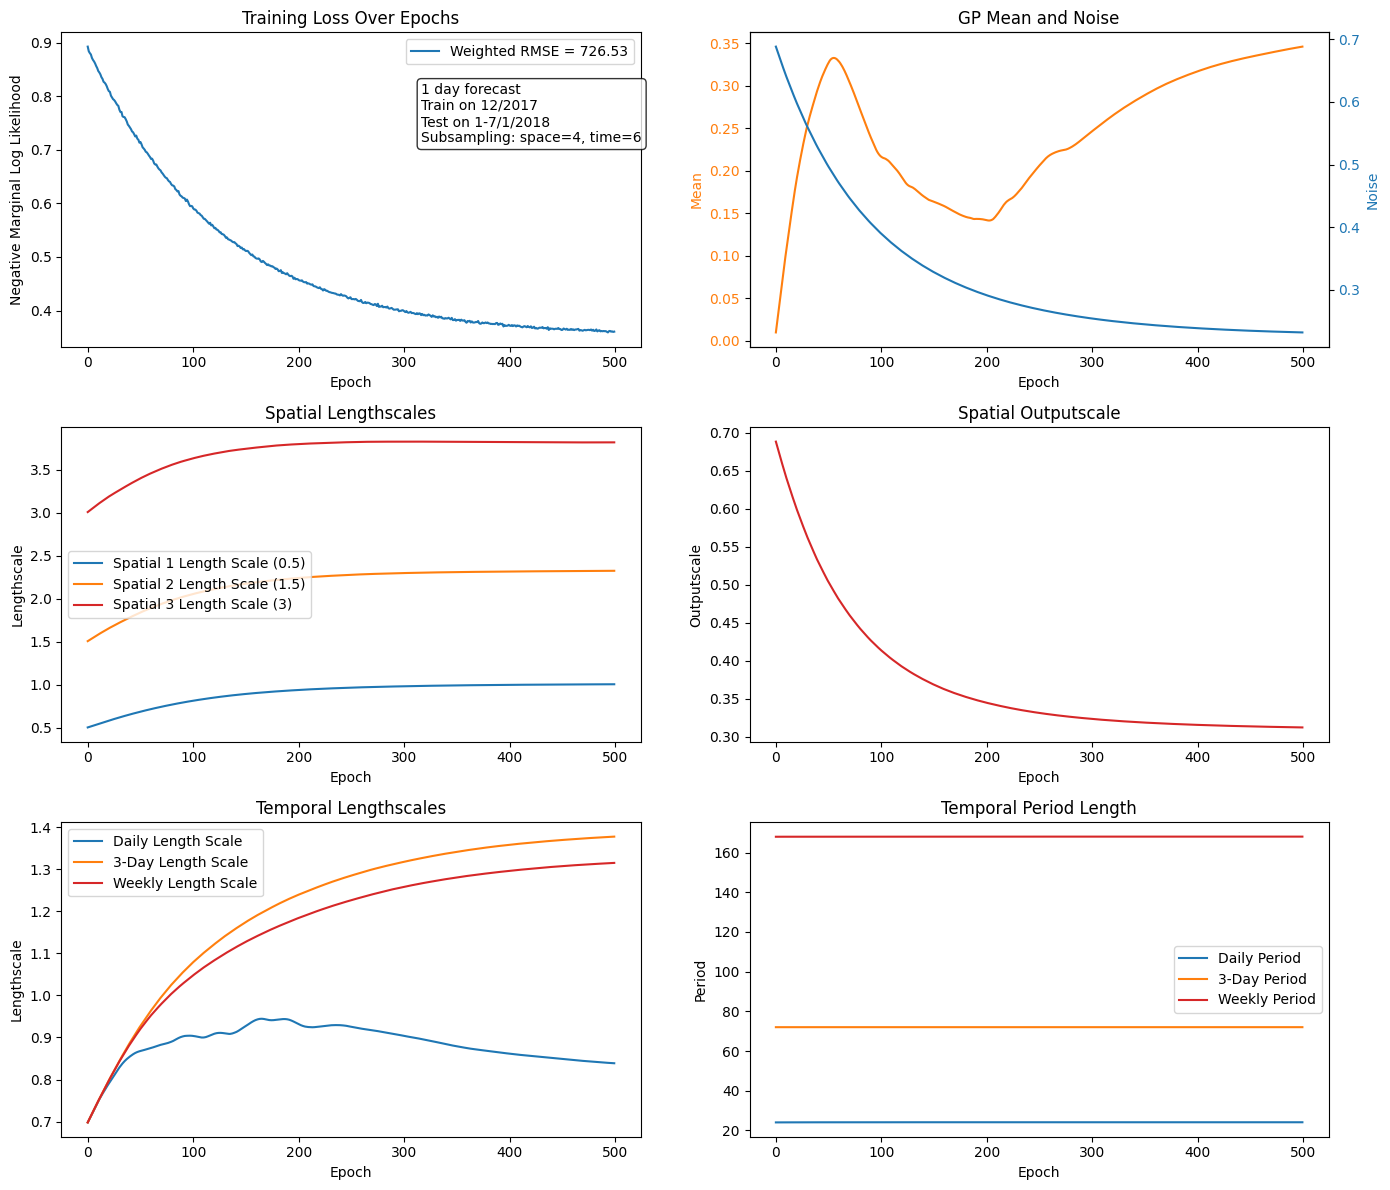

In [16]:
# Convert your tracking list into a DataFrame
df = pd.DataFrame(hyperparams_track)
epochs_range = np.arange(len(df))

# Create a figure with 3 rows and 2 columns of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

# --- Row 1 ---
# Left: Loss
axs[0, 0].plot(epochs_range, df["loss"], label=f'Weighted RMSE = {wrmse:.2f}', color='tab:blue')
axs[0, 0].set_title("Training Loss Over Epochs")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Negative Marginal Log Likelihood")
axs[0, 0].legend()

axs[0, 0].text(
    0.6215, 0.65, 
    f"1 day forecast\nTrain on 12/2017\nTest on 1-7/1/2018\nSubsampling: space={space_subsample}, time={time_subsample}",
    transform=axs[0, 0].transAxes,  # interpret (x, y) as axes-relative
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

# Right: Mean and Noise
axs[0, 1].plot(epochs_range, df["mean"], color='tab:orange', label="Mean")
axs[0, 1].set_title("GP Mean and Noise")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean", color='tab:orange')
axs[0, 1].tick_params(axis='y', labelcolor='tab:orange')
ax_noise = axs[0, 1].twinx()
ax_noise.plot(epochs_range, df["noise"], color='tab:blue', label="Noise")
ax_noise.set_ylabel("Noise", color='tab:blue')
ax_noise.tick_params(axis='y', labelcolor='tab:blue')

# --- Row 2 ---
# Left: Spatial lengthscales
axs[1, 0].plot(epochs_range, df["spatial_1_lengthscale"], label='Spatial 1 Length Scale (0.5)', color='tab:blue')
axs[1, 0].plot(epochs_range, df["spatial_2_lengthscale"], label='Spatial 2 Length Scale (1.5)', color='tab:orange')
axs[1, 0].plot(epochs_range, df["spatial_3_lengthscale"], label='Spatial 3 Length Scale (3)' , color='tab:red')
axs[1, 0].set_title("Spatial Lengthscales")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Lengthscale")
axs[1, 0].legend()

# Right: Spatial outputscale
axs[1, 1].plot(epochs_range, df["spatial_outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].set_title("Spatial Outputscale")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Outputscale")

# --- Row 3 ---
# Left: Temporal lengthscales
axs[2, 0].plot(epochs_range, df["time_lengthscale_daily"], label='Daily Length Scale', color='tab:blue')
axs[2, 0].plot(epochs_range, df["time_lengthscale_three_days"], label='3-Day Length Scale', color='tab:orange')
axs[2, 0].plot(epochs_range, df["time_lengthscale_weekly"], label='Weekly Length Scale', color='tab:red')
axs[2, 0].set_title("Temporal Lengthscales")
axs[2, 0].set_xlabel("Epoch")
axs[2, 0].set_ylabel("Lengthscale")
axs[2, 0].legend()

# Right: Temporal periods
axs[2, 1].plot(epochs_range, df["time_period_daily"], label='Daily Period', color='tab:blue')
axs[2, 1].plot(epochs_range, df["time_period_three_days"], label='3-Day Period', color='tab:orange')
axs[2, 1].plot(epochs_range, df["time_period_weekly"], label='Weekly Period', color='tab:red')
axs[2, 1].set_title("Temporal Period Length")
axs[2, 1].set_xlabel("Epoch")
axs[2, 1].set_ylabel("Period")
axs[2, 1].legend()

plt.tight_layout()
plt.show()

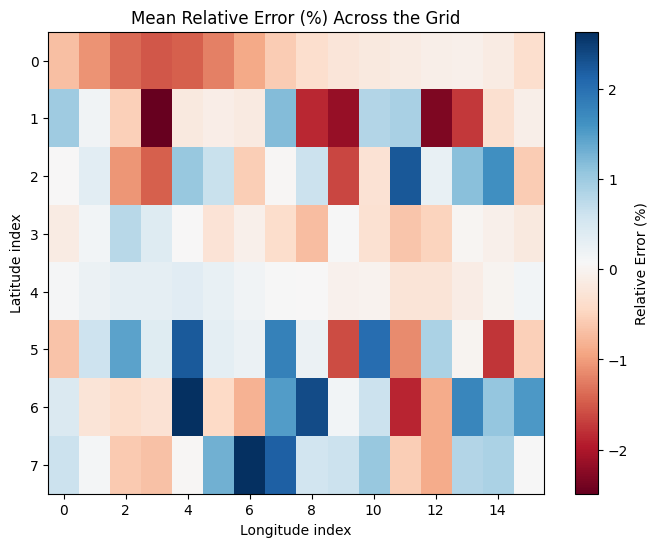

In [17]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100  # shape (ntime, 7, 13)
relative_error_mean = relative_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(relative_error_mean, cmap='RdBu', aspect='auto')
plt.title('Mean Relative Error (%) Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='Relative Error (%)')
plt.show()

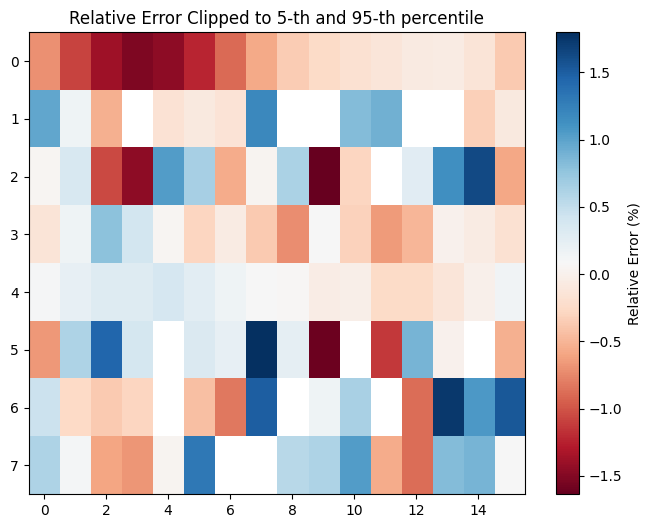

In [18]:
low_q = np.percentile(relative_error_mean, 5)
high_q = np.percentile(relative_error_mean, 95)
masked_error = np.ma.masked_outside(relative_error_mean, low_q, high_q)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error, cmap='RdBu', aspect='auto')
plt.colorbar(im, label='Relative Error (%)')
plt.title('Relative Error Clipped to 5-th and 95-th percentile')
plt.show()

In [19]:
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (6,4), with relative error in percentage: 2.631
Lowest relative error: (1,3), with relative error in percentage: -2.487
Smallest relative error: (5,13), with relative error in percentage: 0.005


In [25]:
results = []
spatial_kernel = model.covar_module.kernels[0]
spatial1 = spatial_kernel.base_kernel.kernels[0]
spatial2 = spatial_kernel.base_kernel.kernels[1]
spatial3 = spatial_kernel.base_kernel.kernels[2]
time_sum_kernel = model.covar_module.kernels[1]
periodic1 = time_sum_kernel.kernels[0]
periodic2 = time_sum_kernel.kernels[1]
periodic3 = time_sum_kernel.kernels[2]

results.append({
    "mean": model.mean_module.constant.item(),
    "noise": model.likelihood.noise.item(),
    "spatial_1_lengthscale": spatial1.lengthscale.item(),
    "spatial_2_lengthscale": spatial2.lengthscale.item(),
    "spatial_3_lengthscale": spatial3.lengthscale.item(),
    "spatial_outputscale": spatial_kernel.outputscale.item(),
    "time_lengthscale_daily": periodic1.lengthscale.item(),
    "time_period_daily": periodic1.period_length.item(),
    "time_lengthscale_three_days": periodic2.lengthscale.item(),
    "time_period_three_days": periodic2.period_length.item(),
    "time_lengthscale_weekly": periodic3.lengthscale.item() ,
    "time_period_weekly": periodic3.period_length.item(),
})
results

[{'mean': 0.34631074077024704,
  'noise': 0.23221952144864713,
  'spatial_1_lengthscale': 1.0062341948444105,
  'spatial_2_lengthscale': 2.3262314237650967,
  'spatial_3_lengthscale': 3.8205026922722083,
  'spatial_outputscale': 0.3120896343855612,
  'time_lengthscale_daily': 0.8387679423431017,
  'time_period_daily': 24.0843023656068,
  'time_lengthscale_three_days': 1.3771512441863505,
  'time_period_three_days': 72.01843312453289,
  'time_lengthscale_weekly': 1.3147269802801058,
  'time_period_weekly': 168.07444654054564}]

## Inspecting best and worse performing grid points


In [21]:
# Prepare training data
X_train, Y_train = create_data(data_train, data_test, lead_time, space_subsample=space_subsample, 
                                time_subsample=time_subsample, device=device)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([120, 8, 16, 4]), Mem: 0.47 MB
Target info --> Shape: torch.Size([15360]), Mem: 0.06 MB


In [22]:
model.eval()
likelihood.eval()
X_train = X_train.view(-1,4)
with torch.no_grad():
    pred_train = model(X_train)
    train_mean = pred_train.mean  
    train_std = pred_train.stddev  

train_mean = train_mean.detach().cpu().numpy()
train_std = train_std.detach().cpu().numpy()
Y_train = Y_train.detach().cpu().numpy()

/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


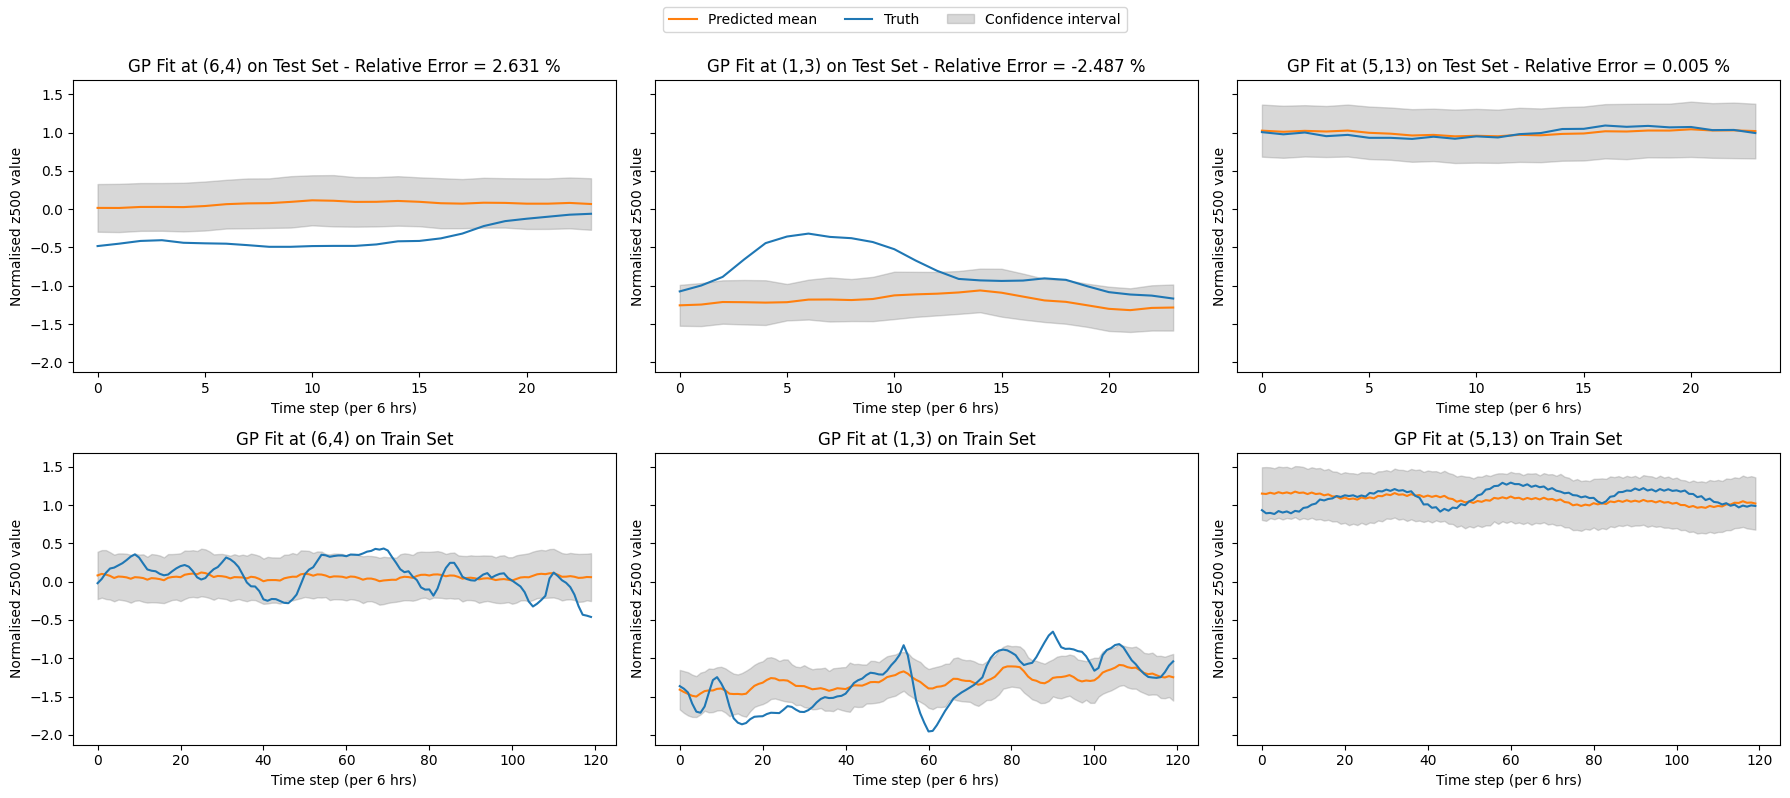

In [23]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=True)

idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

In [21]:
del model, likelihood, X_test, Y_test
torch.cuda.empty_cache()
gc.collect()

36414

Now train on the whole 2017 per montly

In [14]:
lead_time = 24 # 1-day forecasting
space_subsample = 5 # Sub-sample every 5th point
time_subsample = 6 # Sub-sample every 8th hour

monthly_results = []  # For performance and hyperparams by month

# Loop over the months of 2017, training on one month and testing on the following month
for month in range(1, 13):
    if month < 12:
        train_month = f"2017-{month:02d}"
        test_month = f"2017-{month+1:02d}"
    else:
        # For December, train on 2017-12 and test on 2018-01.
        train_month = "2017-12"
        test_month = "2018-01"
    
    print(f"\nTraining on {train_month} and testing on {test_month}...")
    
    z_train = z500.sel(time=slice(train_month, train_month))['z']
    z_test = z500.sel(time=slice(test_month, test_month))['z']
    
    # Normalise the dataset
    data_mean = z_train.mean().load()
    data_std = z_train.std().load()
    data_train = (z_train - data_mean) / data_std
    data_test = (z_test - data_mean) / data_std
    
    model, likelihood, loss_history, X_test, Y_test, lat, lon = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample)
    
    # Evaluate on test data.
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        pred_dist = model(X_test)
        Y_pred = pred_dist.mean
        mse = torch.mean((Y_pred - Y_test) ** 2)
        rmse = torch.sqrt(mse).item()

    spatial_kernel = model.covar_module.kernels[0]
    time_sum_kernel = model.covar_module.kernels[1]
    periodic1 = time_sum_kernel.kernels[0]
    periodic2 = time_sum_kernel.kernels[1]
    #periodic3 = time_sum_kernel.kernels[2]
    
    monthly_results.append({
        "rmse": rmse,
        "mean": model.mean_module.constant.item(),
        "spatial_lengthscale": spatial_kernel.base_kernel.lengthscale.item(),
        "spatial_outputscale": spatial_kernel.outputscale.item(),
        "time_lengthscale_daily": periodic1.lengthscale.item(),
        "time_period_daily": periodic1.period_length.item(),
        "time_lengthscale_weekly": periodic2.lengthscale.item(),
        "time_period_weekly": periodic2.period_length.item(),
        #"time_lengthscale_monthly": periodic3.lengthscale.item() ,
        #"time_period_monthly": periodic3.period_length.item(),
    })
    
    print(f"RMSE on {test_month}: {rmse:.3f}")
    
    # Clean up: delete the model and clear the CUDA cache to release GPU memory.
    del model, likelihood, X_test, Y_test
    torch.cuda.empty_cache()
    gc.collect()


Training on 2017-01 and testing on 2017-02...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([9828, 4]), Mem: 0.30 MB
Target info --> Shape: torch.Size([9828]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 931.63 MB
Peak GPU memory allocated: 46426.66 MB
Training completed
Training time: 533.20s
RMSE on 2017-02: 0.353

Training on 2017-02 and testing on 2017-03...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([9828, 4]), Mem: 0.30 MB
Target info --> Shape: torch.Size([9828]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2395.23 MB
Peak GPU memory allocated: 39243.01 MB
Training completed
Training time: 452.54s
RMSE on 2017-03: 0.311

Training on 2017-03 and testing on 2017-04...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10556, 4]), Mem: 0.32 MB
Target info --> Shape: torch.Size([10556]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


...

Current GPU memory allocated: 2691.09 MB
Peak GPU memory allocated: 48187.42 MB
Training completed
Training time: 542.92s
RMSE on 2017-11: 0.322

Training on 2017-11 and testing on 2017-12...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10556, 4]), Mem: 0.32 MB
Target info --> Shape: torch.Size([10556]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2631.33 MB
Peak GPU memory allocated: 45139.33 MB
Training completed
Training time: 509.23s
RMSE on 2017-12: 0.356

Training on 2017-12 and testing on 2018-01...
Processing Training Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Processing Test Dataset
Combined coords info --> Shape: torch.Size([10920, 4]), Mem: 0.33 MB
Target info --> Shape: torch.Size([10920]), Mem: 0.04 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 2691.11 MB
Peak GPU memory allocated: 48187.44 MB
Training completed
Training time: 550.15s
RMSE on 2018-01: 0.285


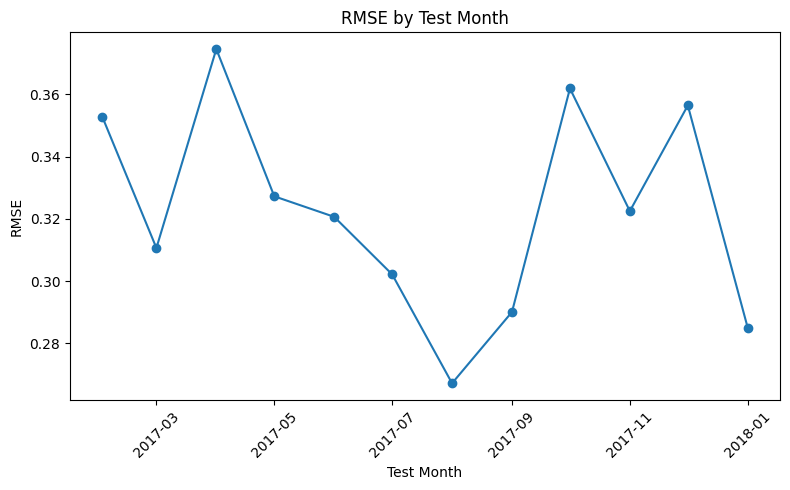

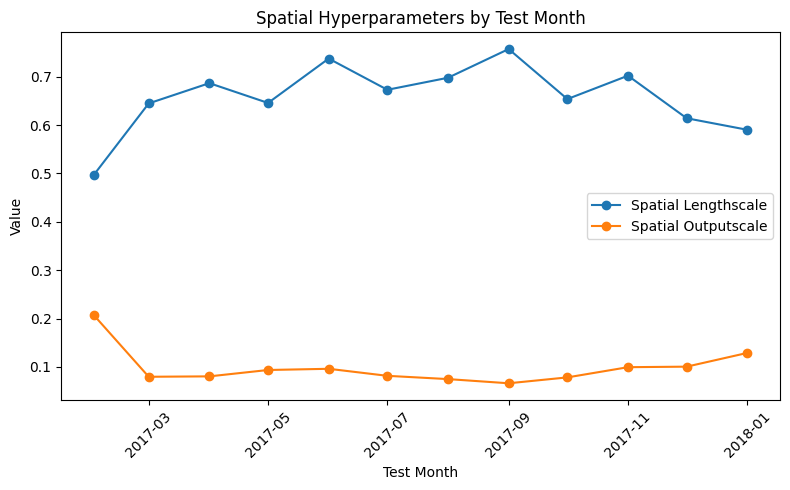

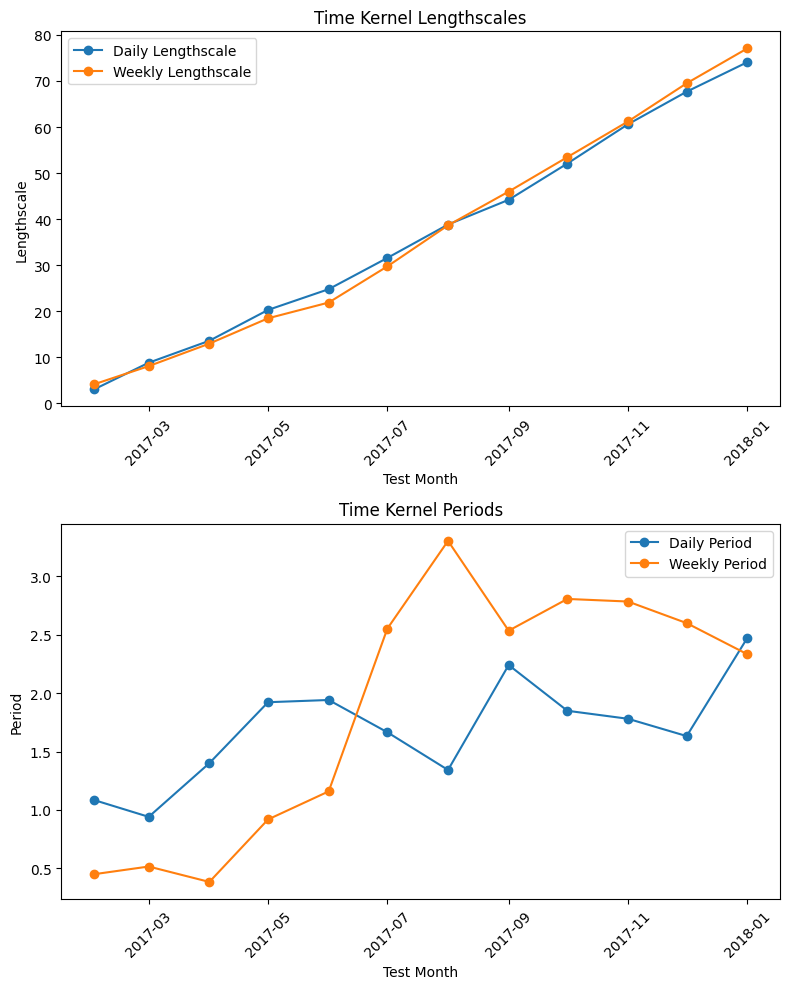

In [15]:
import pandas as pd

# Convert the monthly_results list into a DataFrame.
df = pd.DataFrame(monthly_results)

# Create test month labels assuming the loop order:
# For months 1 to 11, the test month is "2017-{month+1:02d}", and for month 12 it's "2018-01".
test_months = [f"2017-{month+1:02d}" if month < 12 else "2018-01" for month in range(1, 13)]
df["test_month"] = pd.to_datetime(test_months, format="%Y-%m")


# Plot RMSE by Test Month
plt.figure(figsize=(8, 5))
plt.plot(df["test_month"], df["rmse"], marker="o", linestyle="-")
plt.xlabel("Test Month")
plt.ylabel("RMSE")
plt.title("RMSE by Test Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Spatial Hyperparameters
plt.figure(figsize=(8, 5))
plt.plot(df["test_month"], df["spatial_lengthscale"], marker="o", linestyle="-", label="Spatial Lengthscale")
plt.plot(df["test_month"], df["spatial_outputscale"], marker="o", linestyle="-", label="Spatial Outputscale")
plt.xlabel("Test Month")
plt.ylabel("Value")
plt.title("Spatial Hyperparameters by Test Month")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Time Hyperparameters in two subplots:
# One for lengthscales and one for periods.
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Plot time lengthscales for daily, weekly, and monthly kernels.
axs[0].plot(df["test_month"], df["time_lengthscale_daily"], marker="o", linestyle="-", label="Daily Lengthscale")
axs[0].plot(df["test_month"], df["time_lengthscale_weekly"], marker="o", linestyle="-", label="Weekly Lengthscale")
# axs[0].plot(df["test_month"], df["time_lengthscale_monthly"], marker="o", linestyle="-", label="Monthly Lengthscale")
axs[0].set_title("Time Kernel Lengthscales")
axs[0].set_xlabel("Test Month")
axs[0].set_ylabel("Lengthscale")
axs[0].legend()
axs[0].tick_params(axis="x", rotation=45)

# Plot time periods for daily, weekly, and monthly kernels.
axs[1].plot(df["test_month"], df["time_period_daily"], marker="o", linestyle="-", label="Daily Period")
axs[1].plot(df["test_month"], df["time_period_weekly"], marker="o", linestyle="-", label="Weekly Period")
# axs[1].plot(df["test_month"], df["time_period_monthly"], marker="o", linestyle="-", label="Monthly Period")
axs[1].set_title("Time Kernel Periods")
axs[1].set_xlabel("Test Month")
axs[1].set_ylabel("Period")
axs[1].legend()
axs[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()